# 삼양데이타시스템 매출 × 경제지표 상관관계 분석

삼양데이타시스템은 감사보고서 주석에 "사업분야별(공공/제조/금융/통신/서비스/클라우드)
IT Outsourcing 및 System Integration, 솔루션 사업(Mobile, HR)을 영위"한다고 명시된
**IT 서비스(SI/아웃소싱) 회사**다.

> **지표 한계가 다른 계열사보다 훨씬 크다**: IT 서비스업 매출을 직접 설명할 원자재/상품
> 가격 지표가 존재하지 않는다 (곡물처럼 투입 원가가 있는 제조업이 아니라 인건비/용역
> 중심 사업). 그나마 **기업 설비투자(capex) 사이클**이 SI/아웃소싱 수요와 관련 있을
> 것이라는 가정 하에, GDP 설비투자 성장률·정책금리·KOSPI 등 **거시경제 사이클을 대신
> 보는 매우 간접적인 지표**만 썼다. 여기서 낮은 상관관계가 나와도 "경기와 무관하다"는
> 뜻이 아니라 "이 지표들로는 못 잡아낸다"는 뜻일 수 있다.

비상장 계열사라 분기·반기보고서가 없다 — 연 1회 감사보고서만 있어 **연 단위**로 분석한다
(표본 6개 연도).

> **표본 크기 주의**: n=6으로 매우 작다. 상관계수는 참고용 신호조차 되기 어렵다.

공통 계산/시각화 함수는 `eda_utils.py`(같은 폴더)에 있다.

## 0. 환경 설정

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

sys.path.append(str(Path("../../RAG").resolve()))  # dart_parser.py가 있는 폴더
import dart_parser
import eda_utils  # 계열사 노트북 공통 로직 (같은 mandu/Eda 폴더)

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "Malgun Gothic"  # Windows 기본 한글 폰트 (다른 OS라면 폰트명 교체)

In [2]:
DART_DIR = Path("../../RAG/data/dart_xml")
TARGET_COMPANIES = {"삼양데이타시스템(주)", "삼양데이타시스템", "삼양데이타시스템 주식회사"}  # 표기 변형

# 지표 DB(DATABASE_URL)는 Steam_Sales/dashboard/backend/.env 에 있다
DASHBOARD_ENV = Path("../../dashboard/backend/.env")
load_dotenv(DASHBOARD_ENV)

True

## 1. DART 공시에서 연간 매출액 추출

In [3]:
annual_df, failed = eda_utils.extract_annual_metric(DART_DIR, TARGET_COMPANIES, value_col="revenue")
annual_df

성공 6건 / 실패 0건


,file,doc_type,period_from,revenue
period_to,,,,
2020-12-31,20210331002420.xml,감사보고서,2020-01-01,71991
2021-12-31,20220329000676.xml,감사보고서,2021-01-01,84259
2022-12-31,20230329000052.xml,감사보고서,2022-01-01,79066
2023-12-31,20240318000280.xml,감사보고서,2023-01-01,77884
2024-12-31,20250324000099.xml,감사보고서,2024-01-01,78310
2025-12-31,20260323000034.xml,감사보고서,2025-01-01,87074


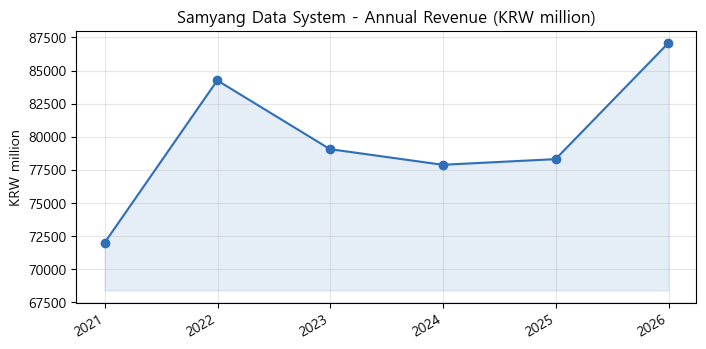

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(annual_df.index, annual_df["revenue"], marker="o", color="#2E6FB8")
ax.fill_between(annual_df.index, annual_df["revenue"], annual_df["revenue"].min() * 0.95, alpha=0.12, color="#2E6FB8")
ax.set_title("Samyang Data System - Annual Revenue (KRW million)")
ax.set_ylabel("KRW million")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.show()

## 2. DB에서 경제지표 로드

IT 서비스 수요와 느슨하게라도 관련 있을 법한 거시 사이클 지표(설비투자, 정책금리,
KOSPI, 소비자심리지수)를 대신 썼다 — 위 서론 참고.

In [5]:
from sqlalchemy import create_engine
import os

engine = create_engine(os.environ["DATABASE_URL"], pool_pre_ping=True)

TARGETS = {
    "ecos_gdp_growth": ["계", "설비투자"],
    "policy_rates": ["한국"],
    "market_yfinance": ["KOSPI", "원달러환율"],
    "ecos_monthly_macro": ["소비자심리지수"],
}

all_series = eda_utils.load_indicator_series(engine, TARGETS)
print(f"{len(all_series)}개 지표 시계열 로드")

5개 지표 시계열 로드


## 3. 연도별 지표 평균과 매출 정렬

In [6]:
aligned = eda_utils.align_indicators_to_periods(annual_df, "revenue", all_series)
aligned

,period_from,revenue,ecos_gdp_growth::계,ecos_gdp_growth::설비투자,policy_rates::한국,market_yfinance::원달러환율,ecos_monthly_macro::소비자심리지수
period_to,,,,,,,
2020-12-31,2020-01-01,71991,1.886617,2.348622,0.500000,1138.062856,90.080000
2021-12-31,2021-01-01,84259,1.171802,1.331893,0.645833,1143.850536,103.433333
2022-12-31,2022-01-01,79066,0.331015,1.193150,2.125000,1291.037695,95.491667
2023-12-31,2023-01-01,77884,0.648543,-0.375803,3.500000,1305.279728,97.191667
2024-12-31,2024-01-01,78310,0.288296,0.720313,3.395833,1361.876494,99.775000
2025-12-31,2025-01-01,87074,0.432640,-0.489286,2.604167,1419.838600,103.891667


## 4. 레벨 기준 상관관계

표본이 6개뿐이라 `min_n`을 낮춰서 계산한다.

In [7]:
level_corr = eda_utils.corr_table(aligned, all_series, "revenue", min_n=5)
level_corr

,indicator,pearson,spearman,n
0,ecos_monthly_macro::소비자심리지수,0.937963,0.828571,6
1,ecos_gdp_growth::설비투자,-0.592466,-0.428571,6
2,ecos_gdp_growth::계,-0.489103,-0.314286,6
3,market_yfinance::원달러환율,0.441486,0.485714,6
4,policy_rates::한국,0.145807,0.028571,6


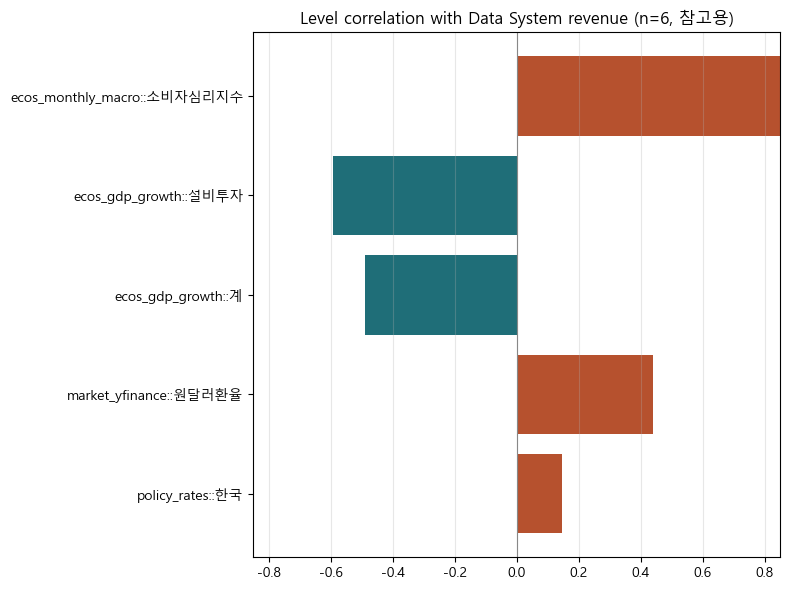

In [8]:
eda_utils.plot_top_correlations(level_corr, "Level correlation with Data System revenue (n=6, 참고용)")

## 5. 전기 대비 변화율(%) 기준 상관관계

In [9]:
pct = aligned.drop(columns=["period_from"]).pct_change().dropna(how="all")
pct_corr = eda_utils.corr_table(pct, all_series, "revenue", min_n=4)
pct_corr

,indicator,pearson,spearman,n
0,ecos_monthly_macro::소비자심리지수,0.907744,1.0,5
1,policy_rates::한국,-0.655862,-0.7,5
2,market_yfinance::원달러환율,-0.633048,-0.7,5
3,ecos_gdp_growth::계,0.094485,0.3,5
4,ecos_gdp_growth::설비투자,0.048861,-0.3,5


## 6. 시차(Lag) 분석

연 단위이므로 lag는 0~1년만 본다.

> **표본 크기 재차 주의**: n=6 수준이라, 여기 나온 어떤 상관계수도 확정된 관계로
> 취급하면 안 된다.

In [10]:
level_df = aligned.drop(columns=["period_from"])
lag_df = eda_utils.lag_correlation_table(level_df, all_series, "revenue", max_lag=2, min_n=4)
lag_df

,indicator,best_lag,best_corr,L0,L1
0,ecos_monthly_macro::소비자심리지수,0,0.937963,0.937963,-0.174158
1,ecos_gdp_growth::설비투자,0,-0.592466,-0.592466,0.311789
2,ecos_gdp_growth::계,0,-0.489103,-0.489103,0.133893
3,market_yfinance::원달러환율,0,0.441486,0.441486,0.147963
4,policy_rates::한국,0,0.145807,0.145807,0.073068


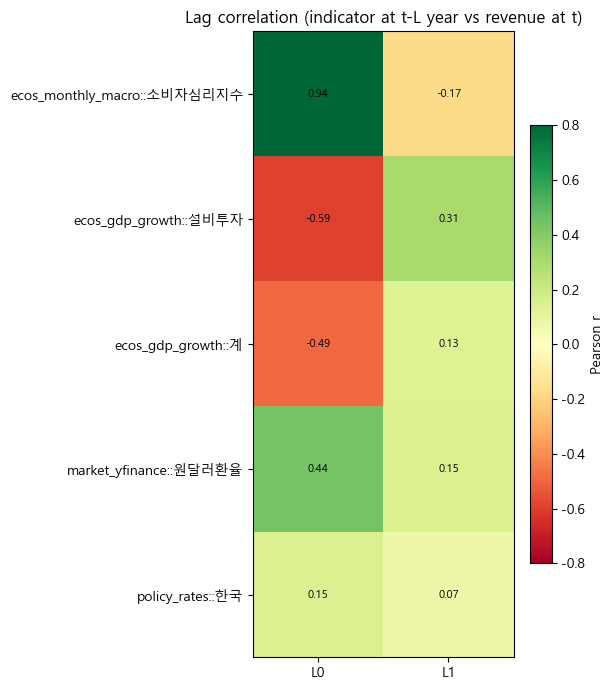

In [11]:
eda_utils.plot_lag_heatmap(lag_df, "Lag correlation (indicator at t-L year vs revenue at t)", max_lag=2, top_n=len(lag_df))

## 결론 및 한계

*(노트북을 실행한 뒤, 위 상관관계 표를 보고 이 셀에 실제 결론을 채워 넣을 것)*

- 표본이 6개 연도뿐이라 상관계수는 통계적으로 의미 있는 수준이 아니다 — 방향성 참고용.
- IT 서비스업 특성상 이 노트북에 쓴 매크로 지표들은 원래 약한 신호일 가능성이 높다.
  더 의미 있는 분석을 하려면 (a) 계열사 자체의 IT 투자 계획/그룹 계열사 실적, (b) 공공
  IT 예산 집행 규모처럼 **이 회사 고객군에 특화된 지표**가 있어야 한다 — 지금 DB에는 없다.